In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from deep_translator import GoogleTranslator
import re
from pandas.api.types import is_string_dtype
from pandas.api.types import is_numeric_dtype
import seaborn as sns

In [18]:
df = pd.read_csv("D:/ITB/Thesis/Preprocessing/儲格設計_原檔(商品資訊)(Translated).csv", sep = None, engine = "python")

In [19]:
# Translate Mandarin into English
translator = GoogleTranslator(source="zh-TW", target="en")

for i, x in df["註記 (Notes)"].items():
    if pd.notna(df.at[i, "Notes_EN"]):
        continue
    if isinstance(x, str):
        df.at[i, "Notes_EN"] = translator.translate(x)
    else:
        df.at[i, "Notes_EN"] = x
    
    df.to_csv("D:/ITB/Thesis/Data/儲格設計_原檔(商品資訊)(Translated).csv", index=False, encoding="utf-8-sig")

In [20]:
# Read the file
df2 = pd.read_csv("D:/ITB/Thesis/Preprocessing/訂單資料(order data).csv", sep = None, engine="python")
df2["创建时间"] = pd.to_datetime(df2["创建时间"], format="%d/%m/%Y %H:%M", errors = "coerce").dt.date
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 321382 entries, 0 to 321381
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   ﻿订单号    321382 non-null  str   
 1   商品编码    321382 non-null  int64 
 2   商品名称    321382 non-null  str   
 3   商品数量    321382 non-null  int64 
 4   创建时间    321382 non-null  object
dtypes: int64(2), object(1), str(2)
memory usage: 12.3+ MB


In [21]:
'''
translator = GoogleTranslator(source="zh-TW", target="en")

#df2["Product Information"] = pd.NA #turn this on by removing the hashtag

for i, x in df2["商品名称"].items():
    if pd.notna(df2.at[i, "Product Information"]):
        continue
    if isinstance(x, str):
        df2.at[i, "Product Information"] = translator.translate(x)
    else:
        df2.at[i, "Product Information"] = x
    
    df2.to_csv("D:/ITB/Thesis/Data/訂單資料(order data).csv", index=False, encoding="utf-8-sig")
'''

'\ntranslator = GoogleTranslator(source="zh-TW", target="en")\n\n#df2["Product Information"] = pd.NA #turn this on by removing the hashtag\n\nfor i, x in df2["商品名称"].items():\n    if pd.notna(df2.at[i, "Product Information"]):\n        continue\n    if isinstance(x, str):\n        df2.at[i, "Product Information"] = translator.translate(x)\n    else:\n        df2.at[i, "Product Information"] = x\n\n    df2.to_csv("D:/ITB/Thesis/Data/訂單資料(order data).csv", index=False, encoding="utf-8-sig")\n'

In [22]:
#Buat Coba-coba, make data hasil translate-an yang ada dulu
df2_temp = df2.dropna() 
df2_temp.head()

,﻿订单号,商品编码,商品名称,商品数量,创建时间
0,DO_0000263618,10000005001,可口可樂330ml,6,2021-08-01
1,DO_0000263618,10002014001,維大力汽水Can330ml,6,2021-08-01
2,DO_0000263618,10002018001,黑松沙士330ml,24,2021-08-01
3,DO_0000263618,10014037001,好聖地100椰子水 350ml,3,2021-08-01
4,DO_0000263618,10020007001,伯朗咖啡原味Can240ml:金車伯朗咖啡,24,2021-08-01


In [23]:
#Cleaning Product Information
#Normalize text in Product Information

df2_temp["clean"] = df2_temp["Product Information"].str.strip().str.lower()
df2_temp.head(5)

KeyError: 'Product Information'

In [ ]:
# Extract the size

pattern = r'(\d+(?:\.\d+)?)\s*?(ml|kg|cm|l|g|m)(?:\*(\d+(?:\.\d+)?)\s*?(ml|kg|cm|l|g|m)?)?'

def extract_size(text):
    match = re.search(pattern, text)
    if not match:
        return None

    if match:
        value, unit, value2, unit2 = match.groups()
        value = float(value)

    
    if value2 and unit2: 
        value2 = float(value2)
        return f"{int(value)}{unit.lower()}{int(value2)}{unit2.lower()}"

    
    return f"{int(value)} {unit.lower()}"    

df2_temp["size"] = df2_temp["Product Information"].apply(extract_size)
df2_temp["clean"] = df2_temp["clean"].str.replace(pattern, "", regex=True, case = False)
df2_temp.head(1)

,﻿﻿﻿订单号,商品编码,商品名称,商品数量,创建时间,Product Information,clean,size,package
1,DO_0000263618,1.000201e+10,維大力汽水Can330ml,6.0,2021-08-01,Victoria Soda Can 330ml,victoria soda can,330 ml,can


In [ ]:
# Extract the Packaging

pack_word = r"(quantity|value)?\s*(can|bag|bottle|box|pack)"

def extract_packaging(text):
    match = re.search(pack_word, text)
    if not match:
        return None
    if match:
        annot, package = match.groups()
    
    if annot:
        return f"{annot.lower()} {package.lower()}"
    
    return f"{package.lower()}"

df2_temp["package"] = df2_temp["clean"].apply(extract_packaging)
df2_temp["clean"] = df2_temp["clean"].str.replace(pack_word, "", regex=True, case = False)
df2_temp.head(10)

,﻿﻿﻿订单号,商品编码,商品名称,商品数量,创建时间,Product Information,clean,size,package
1,DO_0000263618,1.000201e+10,維大力汽水Can330ml,6.0,2021-08-01,Victoria Soda Can 330ml,victoria soda,330 ml,can
4,DO_0000263618,1.002001e+10,伯朗咖啡原味Can240ml:金車伯朗咖啡,24.0,2021-08-01,Brown Coffee Original Can 240ml: Jin Che Brown...,brown coffee original : jin che brown coffee,240 ml,can
18,DO_0000263618,1.450109e+10,一度贊-紅燒牛肉(袋) 200g,3.0,2021-08-01,Yiyi Zan - braised beef (bag) 200g,yiyi zan - braised beef (),200 g,bag
19,DO_0000263618,1.450201e+10,統一肉燥(包) 85g,10.0,2021-08-01,Uni-President Dried Pork (Pack) 85g,uni-president dried pork (),85 g,pack
20,DO_0000263618,1.450211e+10,一度贊-爌肉(袋) 200g,3.0,2021-08-01,Yiyi Zan-Yu Pork (bag) 200g,yiyi zan-yu pork (),200 g,bag
21,DO_0000263618,1.450300e+10,統一鮮蝦麵(包) 83g,5.0,2021-08-01,Uni-President Shrimp Noodles (Pack) 83g,uni-president shrimp noodles (),83 g,pack
22,DO_0000263618,1.450501e+10,維力炸醬麵(包) 90g:維力炸醬麵(包),10.0,2021-08-01,Weili Zhajiang Noodles (Pack) 90g:Weili Zhajia...,weili zhajiang noodles () :weili zhajiang nood...,90 g,pack
24,DO_0000263618,1.450609e+10,農心辛拉麵超值包120g x5,1.0,2021-08-01,Nongshim Shin Ramen Value Pack 120g x5,nongshim shin ramen x5,120 g,value pack
25,DO_0000263618,1.450901e+10,龍口口味粉絲(量販包) 720g,2.0,2021-08-01,Longkou Flavor Vermicelli (Quantity Pack) 720g,longkou flavor vermicelli (),720 g,quantity pack
29,DO_0000263618,1.483202e+10,同榮茄汁鯖魚罐(紅) 230g,3.0,2021-08-01,Tong Rong canned mackerel with tomato sauce (r...,tong rongned mackerel with tomato sauce (red),230 g,can


In [ ]:
# Remove duplicate alias

df2_temp["clean"] = df2_temp['clean'].str.split(":").str[0]
df2_temp.head(5)

,﻿﻿﻿订单号,商品编码,商品名称,商品数量,创建时间,Product Information,clean,size,package
1,DO_0000263618,1.000201e+10,維大力汽水Can330ml,6.0,2021-08-01,Victoria Soda Can 330ml,victoria soda,330 ml,can
4,DO_0000263618,1.002001e+10,伯朗咖啡原味Can240ml:金車伯朗咖啡,24.0,2021-08-01,Brown Coffee Original Can 240ml: Jin Che Brown...,brown coffee original,240 ml,can
18,DO_0000263618,1.450109e+10,一度贊-紅燒牛肉(袋) 200g,3.0,2021-08-01,Yiyi Zan - braised beef (bag) 200g,yiyi zan - braised beef (),200 g,bag
19,DO_0000263618,1.450201e+10,統一肉燥(包) 85g,10.0,2021-08-01,Uni-President Dried Pork (Pack) 85g,uni-president dried pork (),85 g,pack
20,DO_0000263618,1.450211e+10,一度贊-爌肉(袋) 200g,3.0,2021-08-01,Yiyi Zan-Yu Pork (bag) 200g,yiyi zan-yu pork (),200 g,bag


In [ ]:
# Final Clean
df2_temp["clean"] = df2_temp["clean"].str.replace("()", "", regex = True).replace(r's+', "", regex = True)

In [ ]:
df2_temp.to_csv("D:/ITB/Thesis/Data/訂單資料(order data) coba coba.csv", index=False, encoding="utf-8-sig")
df2_temp.head(5)

,﻿﻿﻿订单号,商品编码,商品名称,商品数量,创建时间,Product Information,clean,size,package
1,DO_0000263618,1.000201e+10,維大力汽水Can330ml,6.0,2021-08-01,Victoria Soda Can 330ml,victoria oda,330 ml,can
4,DO_0000263618,1.002001e+10,伯朗咖啡原味Can240ml:金車伯朗咖啡,24.0,2021-08-01,Brown Coffee Original Can 240ml: Jin Che Brown...,brown coffee original,240 ml,can
18,DO_0000263618,1.450109e+10,一度贊-紅燒牛肉(袋) 200g,3.0,2021-08-01,Yiyi Zan - braised beef (bag) 200g,yiyi zan - braied beef (),200 g,bag
19,DO_0000263618,1.450201e+10,統一肉燥(包) 85g,10.0,2021-08-01,Uni-President Dried Pork (Pack) 85g,uni-preident dried pork (),85 g,pack
20,DO_0000263618,1.450211e+10,一度贊-爌肉(袋) 200g,3.0,2021-08-01,Yiyi Zan-Yu Pork (bag) 200g,yiyi zan-yu pork (),200 g,bag


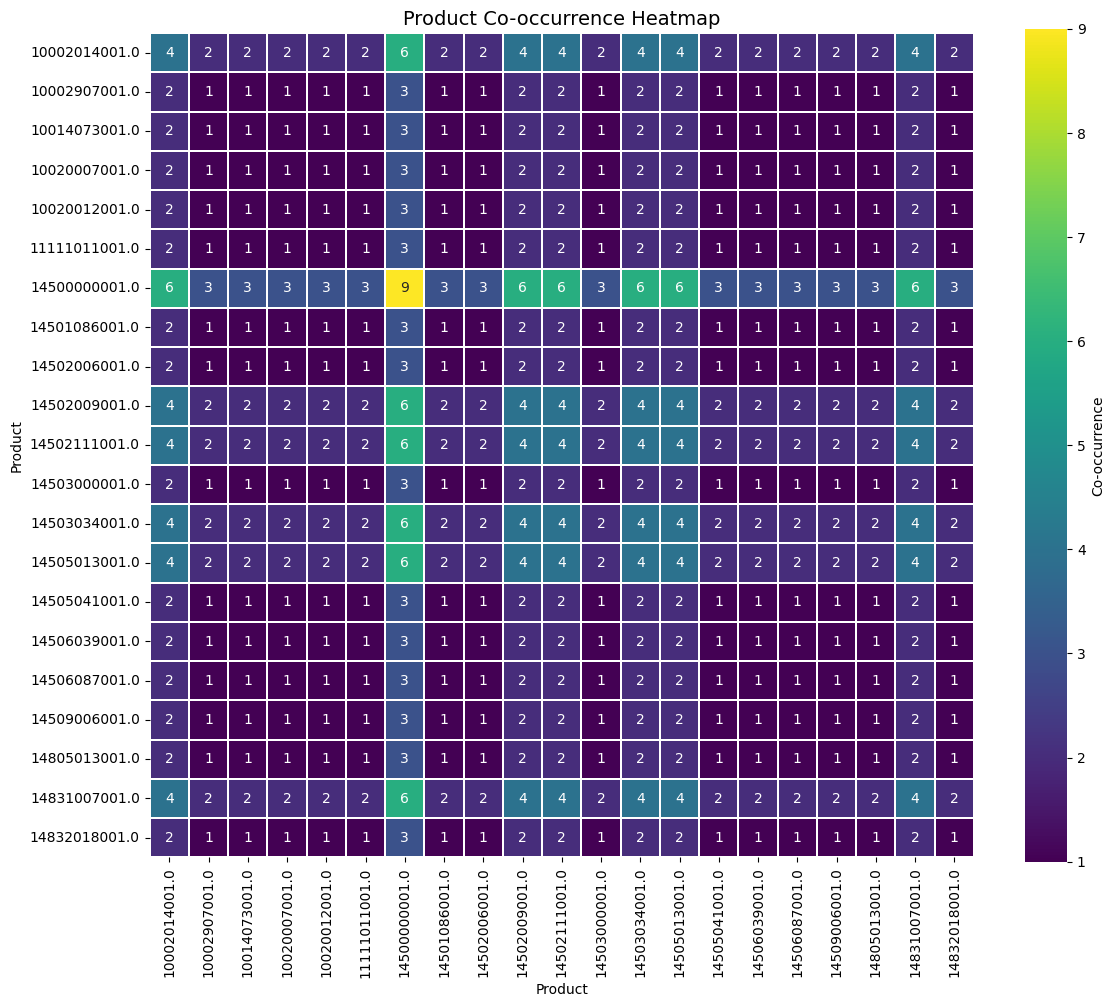

In [ ]:
incidence = pd.crosstab(df2_temp["创建时间"].astype(str), df2_temp["商品编码"])
co_occurrence = incidence.T @ incidence

plt.figure(figsize=(12, 10))

sns.heatmap(co_occurrence, cmap="viridis", square=True, linewidths=0.3, cbar_kws={"label": "Co-occurrence"}, annot = True)

plt.title("Product Co-occurrence Heatmap", fontsize=14)
plt.xlabel("Product")
plt.ylabel("Product")

plt.tight_layout()
plt.show()


Using Item ID

In [28]:
df3 = pd.read_csv("D:/ITB/Thesis/Preprocessing/訂單資料(order data).csv", header = 0, sep = None, engine="python")
df3["创建时间"] = pd.to_datetime(df3["创建时间"], format="%d/%m/%Y %H:%M")
df3.dtypes

订单号               str
商品编码             int64
商品名称               str
商品数量             int64
创建时间    datetime64[us]
dtype: object

In [29]:
df3["商品编码"] = df3["商品编码"].astype(str).str[:2].astype(int)
df3["创建时间"] = pd.to_datetime(df3["创建时间"], errors="coerce").dt.date

df3.head(5)

,﻿订单号,商品编码,商品名称,商品数量,创建时间
0,DO_0000263618,10,可口可樂330ml,6,2021-08-01
1,DO_0000263618,10,維大力汽水Can330ml,6,2021-08-01
2,DO_0000263618,10,黑松沙士330ml,24,2021-08-01
3,DO_0000263618,10,好聖地100椰子水 350ml,3,2021-08-01
4,DO_0000263618,10,伯朗咖啡原味Can240ml:金車伯朗咖啡,24,2021-08-01


In [30]:
daily_picking = df3.groupby("创建时间", as_index= False)["商品数量"].sum()
daily_picking.info

<bound method DataFrame.info of           创建时间    商品数量
0   2021-08-01   99870
1   2021-08-02   84373
2   2021-08-03  105909
3   2021-08-04  103358
4   2021-08-05  103514
5   2021-08-06   55793
6   2021-08-07   59666
7   2021-08-08   92685
8   2021-08-09  105170
9   2021-08-10  103890
10  2021-08-11  121117
11  2021-08-12  129572
12  2021-08-13  104620
13  2021-08-14  111067
14  2021-08-15  148813
15  2021-08-16  133923
16  2021-08-17  153388
17  2021-08-18  189155
18  2021-08-19  154939
19  2021-08-20  168837
20  2021-08-21   80932>

In [31]:
daily_picking_item = df3.groupby(["商品编码", "创建时间"], as_index = False)["商品数量"].sum()
daily_picking_item.info

<bound method DataFrame.info of      商品编码        创建时间   商品数量
0      10  2021-08-01  57527
1      10  2021-08-02  45706
2      10  2021-08-03  61736
3      10  2021-08-04  61261
4      10  2021-08-05  57521
..    ...         ...    ...
317    66  2021-08-15      6
318    66  2021-08-21      2
319    76  2021-08-01      1
320    76  2021-08-10      3
321    76  2021-08-21      1

[322 rows x 3 columns]>

In [32]:
sorted_item = df3.groupby(["商品编码"], as_index = False)["商品数量"].sum()
sorted_item = sorted_item.sort_values("商品数量", axis = 0, ascending= False)
sorted_item.info

<bound method DataFrame.info of     商品编码     商品数量
0     10  1336223
3     14   676316
2     12   238526
4     15   116168
1     11    30037
6     31     9253
7     32     1117
5     30     1075
10    35      514
12    41      420
8     33      287
16    65      222
15    61      169
14    60      102
17    66       71
9     34       53
13    42       29
18    76        5
11    40        4>

Text(0.5, 0.98, 'Picking Trend August')

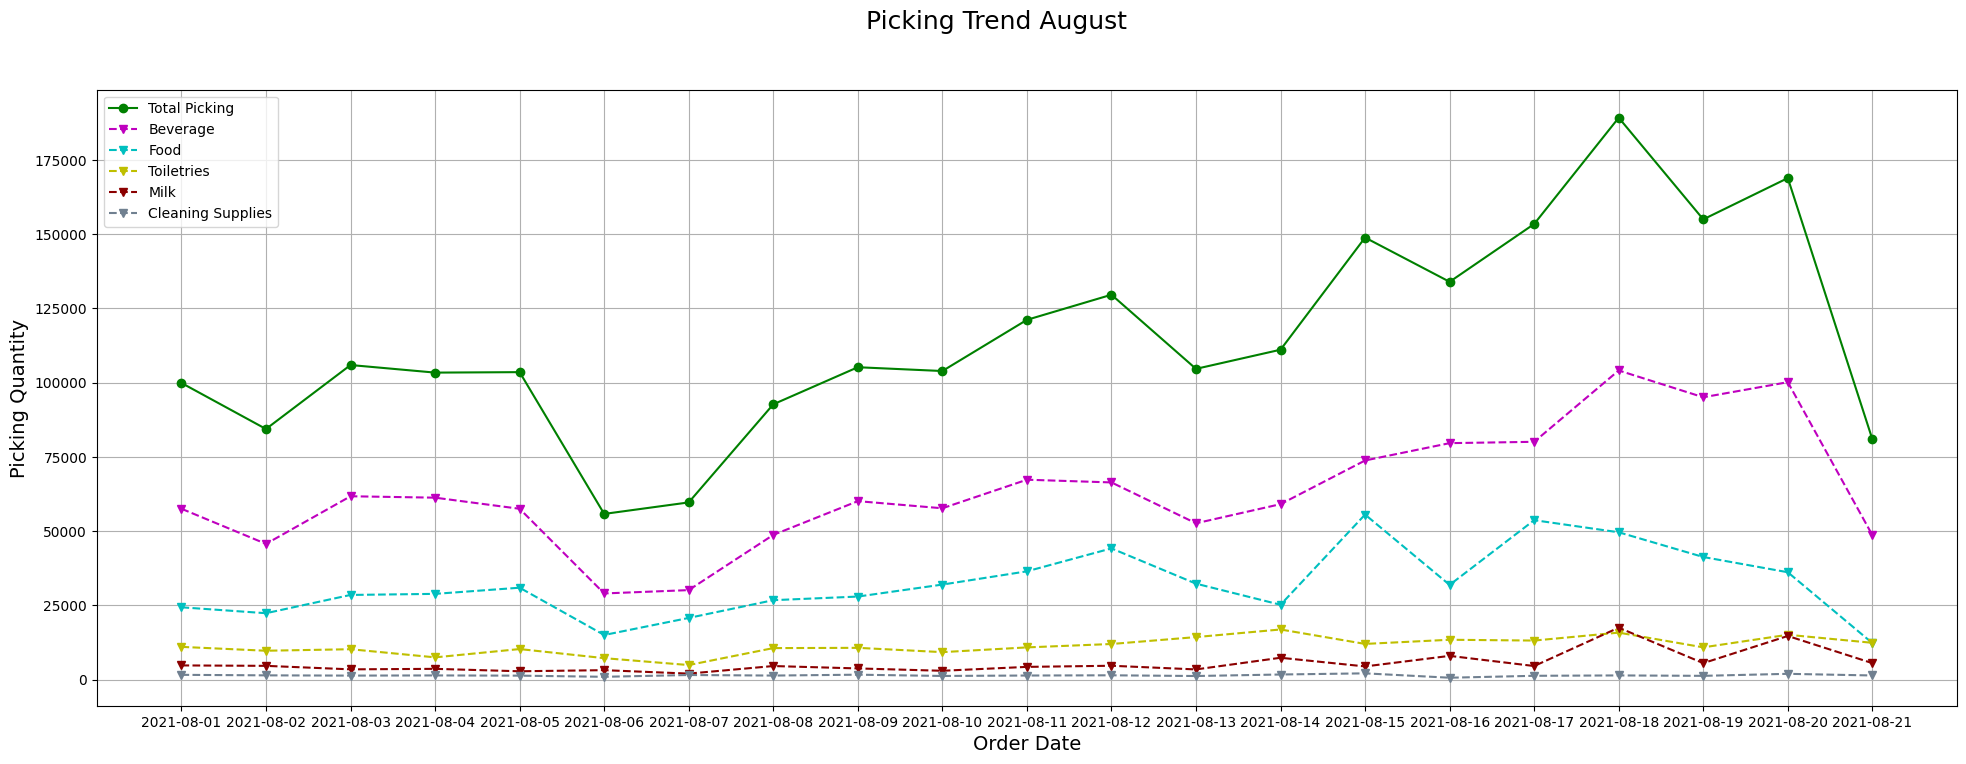

In [33]:
highest_order = daily_picking_item[daily_picking_item["商品编码"] == 10]
second_order = daily_picking_item[daily_picking_item["商品编码"] == 14]
third_order = daily_picking_item[daily_picking_item["商品编码"] == 12]
fourth_order = daily_picking_item[daily_picking_item["商品编码"] == 15]
fifth_order = daily_picking_item[daily_picking_item["商品编码"] == 11]

fig, ax = plt.subplots(1,1, figsize= (24,8))
ax.plot(daily_picking["创建时间"].astype(str), daily_picking["商品数量"], "o-", color ="g")
ax.plot(daily_picking["创建时间"].astype(str), highest_order["商品数量"], "v--m")
ax.plot(daily_picking["创建时间"].astype(str), second_order["商品数量"], "v--c")
ax.plot(daily_picking["创建时间"].astype(str), third_order["商品数量"], "v--y")
ax.plot(daily_picking["创建时间"].astype(str), fourth_order["商品数量"], "v--", color = "darkred")
ax.plot(daily_picking["创建时间"].astype(str), fifth_order["商品数量"], "v--", color = "slategray")
ax.set_xlabel("Order Date", fontsize = 14)
ax.set_ylabel("Picking Quantity", fontsize = 14)
ax.grid(True)
ax.legend(["Total Picking", "Beverage", "Food", "Toiletries", "Milk", "Cleaning Supplies" ])

fig.suptitle("Picking Trend August", ha = "center", x = 0.5, fontsize = 18)

In [ ]:
DensityPicking = df3.groupby(["商品编码"], as_index= False)["商品数量"].sum()
DensityPicking.info

<bound method DataFrame.info of              商品编码   商品数量
0     10000001001    187
1     10000002001   9976
2     10000003001   2832
3     10000004001   2104
4     10000005001  11670
...           ...    ...
7814  65151027001      8
7815  66502013001     15
7816  66511009001     49
7817  66511056001      7
7818  76312151001      5

[7819 rows x 2 columns]>

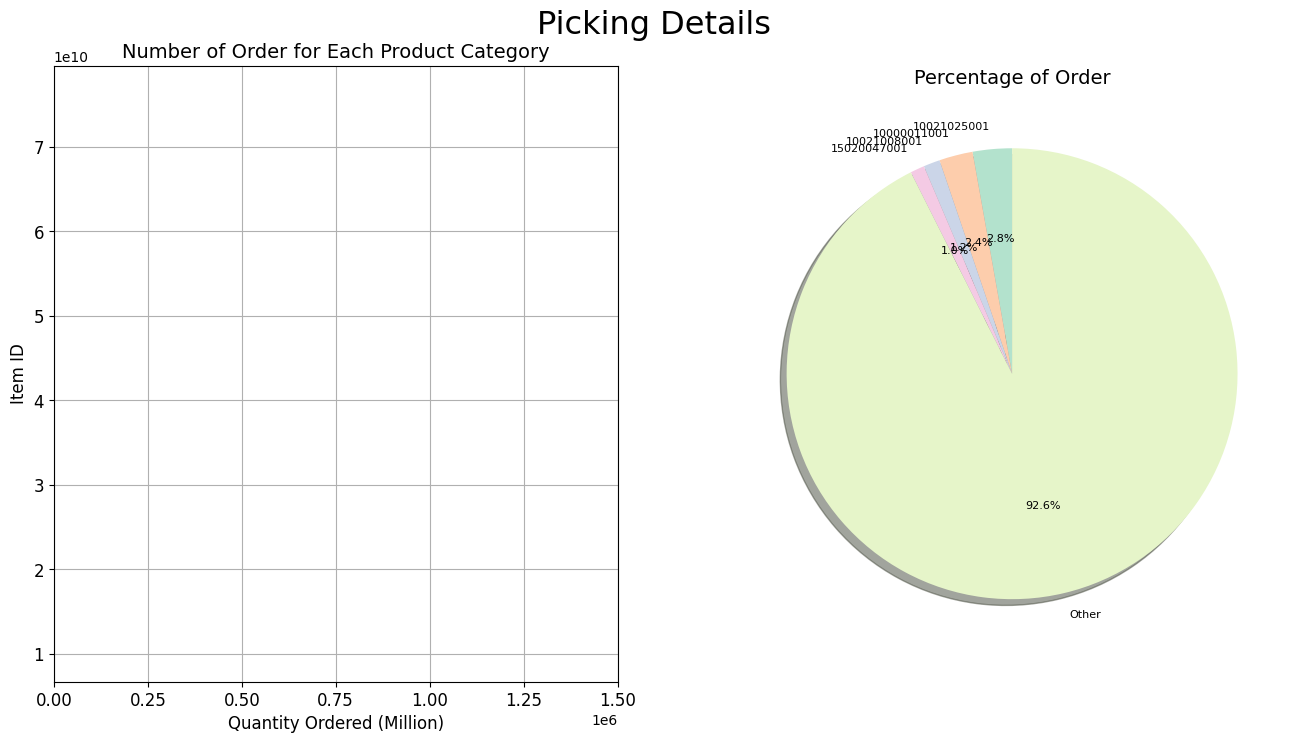

In [ ]:
#Picking of each Item

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (16,8))

ax1.barh(DensityPicking["商品编码"], DensityPicking["商品数量"], align = "center", color = "teal")
ax1.set_xlabel("Quantity Ordered (Million)", fontsize = 12)
ax1.set_ylabel("Item ID", fontsize = 12)
ax1.tick_params(axis = "both", labelsize = 12)
ax1.set_xlim(0, 1_500_000)
ax1.set_xticks([0, 250_000, 500_000, 750_000, 1_000_000, 1_250_000, 1_500_000])
ax1.grid(True)
ax1.set_title("Number of Order for Each Product Category", fontsize = 14)

tmp = DensityPicking.copy()
top = DensityPicking.sort_values("商品数量", ascending=False).head(4)
other = tmp["商品数量"].sum() - top["商品数量"].sum()
pie_df = pd.concat([top, pd.DataFrame([{"商品编码": "Other", "商品数量": other}])], ignore_index=True)

ax2.pie(pie_df["商品数量"], labels= pie_df["商品编码"], autopct="%0.01f%%", startangle=90, shadow = True, colors=plt.cm.Pastel2.colors, textprops={'fontsize': 8},)
ax2.set_title("Percentage of Order", fontsize = 14)

fig.suptitle("Picking Details", fontsize=23, x=0.5, y = 0.95, ha="center")
fig.align_titles = "center"

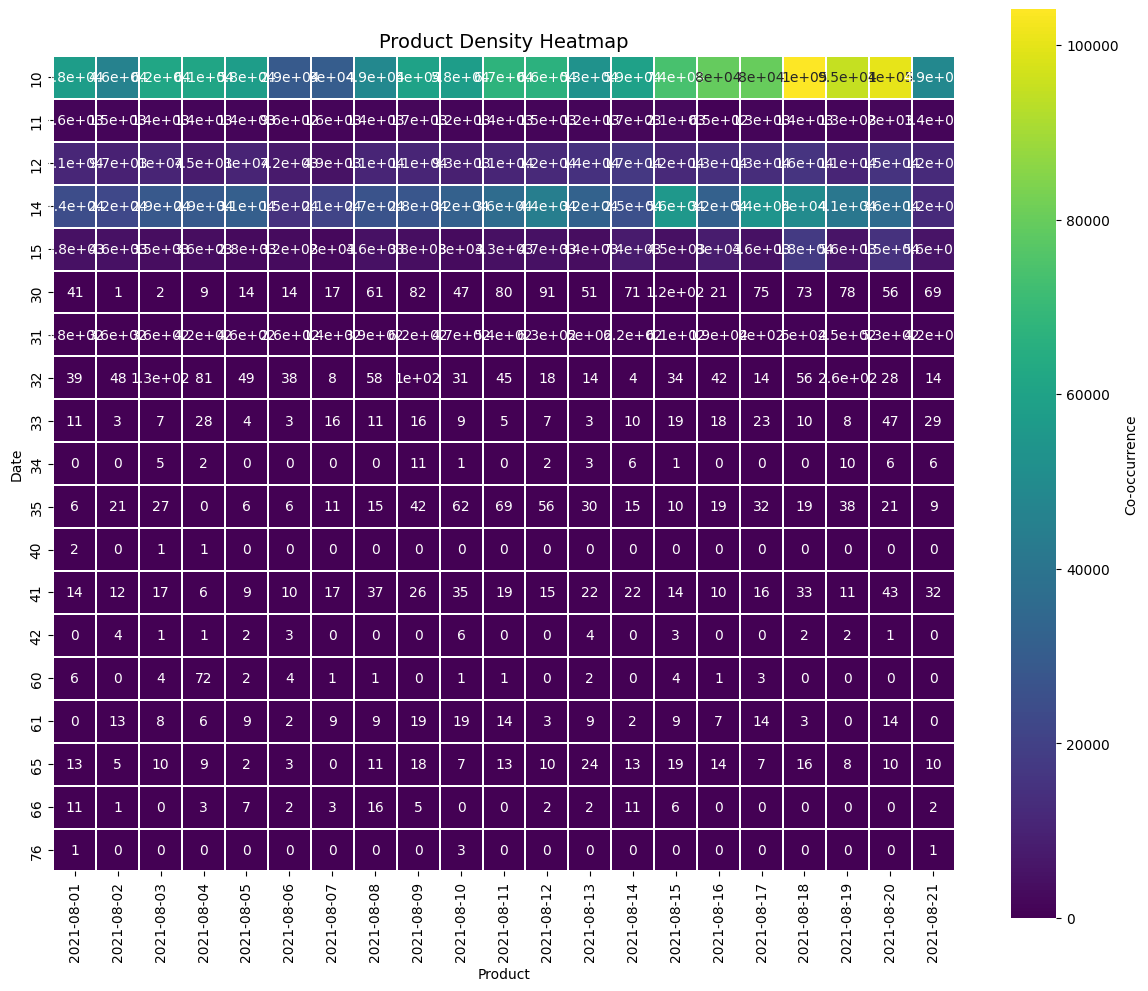

In [ ]:
heatmap_data = daily_picking_item.pivot_table(index="商品编码",columns="创建时间",values="商品数量",aggfunc="sum",fill_value=0)

plt.figure(figsize=(12, 10))

sns.heatmap(heatmap_data, cmap="viridis", square=True, linewidths=0.3, cbar_kws={"label": "Co-occurrence"}, annot = True)
plt.title("Product Density Heatmap", fontsize=14)
plt.xlabel("Product")
plt.ylabel("Date")

plt.tight_layout()
plt.show()

In [ ]:
'''
Since the quantity is predetermined, unique products are determined 
using the product name as well as the quantity it ordered. 
'''

# Read the file
path_file = "D:/ITB/Thesis/Data/訂單資料(order data).csv"
df = pd.read_csv(path_file, sep = ';', engine='python', encoding='utf-8-sig')
df.info()

# Check unique value
# df['商品名称'].nunique()

# Test: Create a dataframe with 

df_new = df['商品名称'].value_counts().reset_index()
df_new

path_file_uniqueid = "D:/ITB/Thesis/Data/uniqueid.csv"
df_new.to_csv(path_file_uniqueid, index=False, encoding='utf-8-sig', sep = ';')